# Health Indicator Analysis
**Team Member: [Diego Marshal]**

## Overview
This analysis evaluates Pittsburgh neighborhoods based on health resources for our "Best Neighborhood" project. I'm responsible for the Health metric.

In [2]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Step 2: Load and explore the data from WPRDC
file_path = 'Covid_Deaths_by_Neighborhood.csv'
df = pd.read_csv(file_path)

print("=== Data Basic Information ===")
print(f"Data shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

=== Data Basic Information ===
Data shape: (221, 14)

Column names:
['_id', 'neighborhood_municipality', 'individuals_tested', 'infections', 'reinfections', 'deaths', 'hospitalizations', 'tests', 'postives', 'ag_tests', 'positive_ag_tests', 'pcr_tests', 'positive_pcr_tests', 'update_date']

First 5 rows:


,_id,neighborhood_municipality,individuals_tested,infections,reinfections,deaths,hospitalizations,tests,postives,ag_tests,positive_ag_tests,pcr_tests,positive_pcr_tests,update_date
0,92401,Aleppo,1103,1941,152,19,28,4723,336,2358,99,2364,235,2023-05-15
1,92402,Allegheny Center (Pittsburgh),1010,1414,174,5,15,2994,379,388,46,2607,333,2023-05-15
2,92403,Allegheny West (Pittsburgh),350,460,70,0,5,1219,109,243,17,976,92,2023-05-15
3,92404,Allentown (Pittsburgh),1470,3017,509,2,37,5488,641,1295,85,4189,555,2023-05-15
4,92405,Arlington (Pittsburgh),1073,2227,347,9,34,4492,535,1046,108,3443,426,2023-05-15


## Step 2: Data Loading
We load the Allegheny County COVID-19 counts data. This dataset contains:
- Neighborhood information
- Infections and individuals tested 
- Deaths and Hospitalizations

In [4]:
# Step 3: Data cleaning and preparation
print("=== Data Cleaning ===")

# Create a new DataFrame with only needed columns
health_df = df[['neighborhood_municipality', 'tests', 'postives']].copy()

# Remove any missing values
health_df = health_df.dropna()

print("Cleaned data shape:", health_df.shape)
print("\nFirst 10 communities:")
display(health_df.head(10))

=== Data Cleaning ===
Cleaned data shape: (221, 3)

First 10 communities:


,neighborhood_municipality,tests,postives
0,Aleppo,4723,336
1,Allegheny Center (Pittsburgh),2994,379
2,Allegheny West (Pittsburgh),1219,109
3,Allentown (Pittsburgh),5488,641
4,Arlington (Pittsburgh),4492,535
5,Arlington Heights (Pittsburgh),565,44
6,Aspinwall,6982,618
7,Avalon,11337,1180
8,Baldwin Borough,54322,6760
9,Baldwin Township,4377,624


## Step 3: Data Preparation
In this critical step, we prepare the data for analysis:

**Data Selection**: We focus on three key columns:
- `neighborhood_municipality`: Geographic identifier for each community
- `tests`: Total number of tests taken in the community
- `positives`: Total number of tests taken that were positive for COVID

**Data Cleaning**:
- Remove records with missing values to ensure data quality
- Handle any data inconsistencies or formatting issues
- Verify the data ranges and distributions

This process ensures we work with reliable, complete data for accurate results.



In [5]:
# Step 4: Normalization and ranking
print("=== Creating Health Scores and Rankings ===")

# Normalization function
def normalize_scores(series, series2):
    return 1 - (series2 / series)

# Handle duplicate communities by summing their student counts
health_final = health_df.groupby('neighborhood_municipality').agg({
    'tests': 'sum',
    'postives': 'sum'
}).reset_index()

# Apply normalization
health_final['health_score'] = normalize_scores(health_final['tests'], health_final['postives'])

# Create rankings (higher score = better rank = smaller number)
health_final['health_rank'] = health_final['health_score'].rank(ascending=False)

# Sort by education score
health_final_sorted = health_final.sort_values('health_score', ascending=False)

print("Top 15 communities by health index:")
display(health_final_sorted.head(15))

print("\nBottom 5 communities by health index:")
display(health_final_sorted.tail(5))

=== Creating Health Scores and Rankings ===
Top 15 communities by health index:


,neighborhood_municipality,tests,postives,health_score,health_rank
183,Squirrel Hill North (Pittsburgh),77946,2018,0.974110,1.0
198,Undefined,123297,4268,0.965384,2.0
82,Glen Hazel (Pittsburgh),10869,404,0.962830,3.0
211,West Oakland (Pittsburgh),12540,503,0.959888,4.0
135,North Shore (Pittsburgh),2421,101,0.958282,5.0
134,North Oakland (Pittsburgh),25668,1178,0.954106,6.0
168,Shadyside (Pittsburgh),63500,3056,0.951874,7.0
140,Oakmont,36934,1811,0.950967,8.0
177,Southside Flats (Pittsburgh),49974,2492,0.950134,9.0
91,Haysville,272,14,0.948529,10.0



Bottom 5 communities by health index:


,neighborhood_municipality,tests,postives,health_score,health_rank
128,Mt. Oliver (Pittsburgh),720,110,0.847222,217.0
176,South Versailles,680,104,0.847059,218.0
205,Wall,940,167,0.822340,219.0
195,Trafford,84,15,0.821429,220.0
109,Lincoln,1746,312,0.821306,221.0


## Step 4: Data Normalization Function

We define a normalization function to standardize our education scores:

**Purpose**: Convert raw student enrollment numbers to a consistent 0-1 scale
**Method**: Divide total number of positives by the total number of tests, and subtract this from 1

This allows fair comparison between neighborhoods of different sizes and ensures all scores are on the same scale for ranking. The division is subtracted from 1 to reverse the score so that the neighborhoods with less positive tests have a higher score.

=== Creating Health Index Chart ===


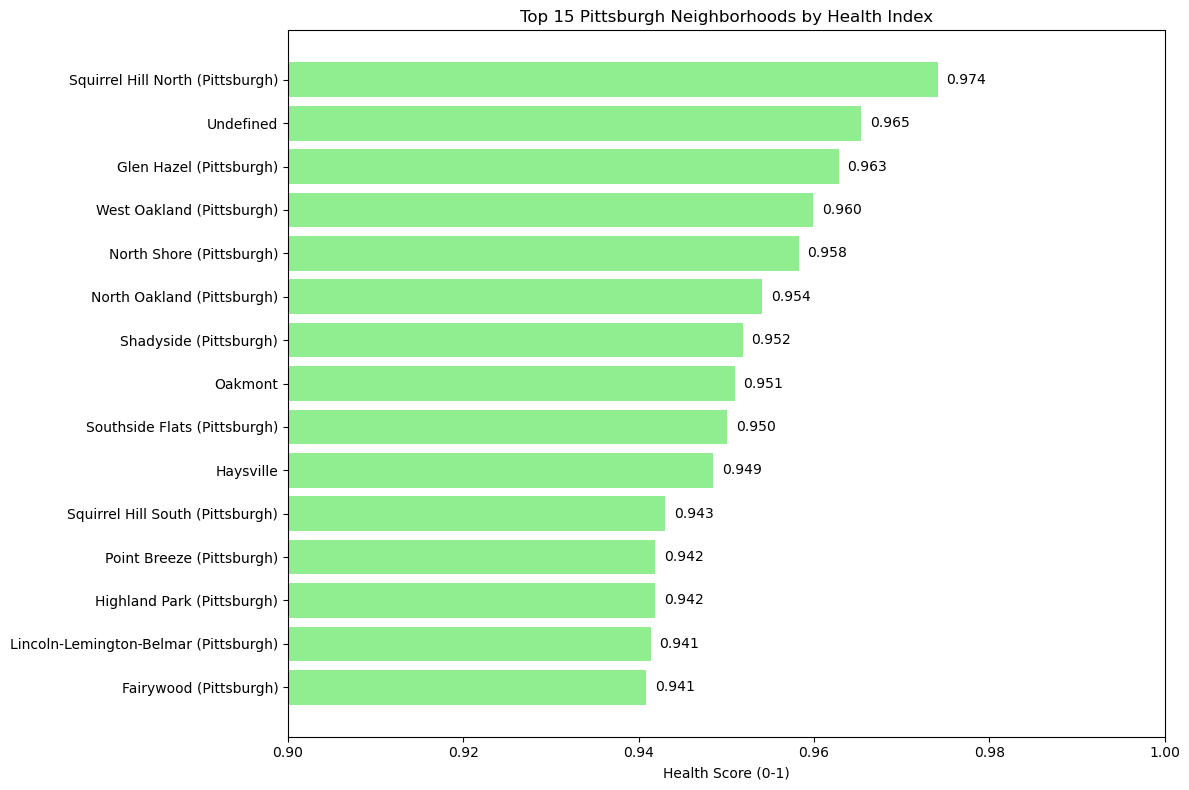

Total number of unique communities: 221
Community with highest health score: Squirrel Hill North (Pittsburgh) (Score: 0.974)
Community with lowest health score: Lincoln (Score: 0.821)


In [12]:
# Step 5: Create visualization
print("=== Creating Health Index Chart ===")

plt.figure(figsize=(12, 8))

# Select top 15 communities
top_15 = health_final_sorted.head(15)

# Create horizontal bar chart
bars = plt.barh(top_15['neighborhood_municipality'], top_15['health_score'], color='lightgreen')
plt.xlim(0.9, 1)
plt.xlabel('Health Score (0-1)')
plt.title('Top 15 Pittsburgh Neighborhoods by Health Index')
plt.gca().invert_yaxis()  # Put highest score at top

# Add value labels on bars
for bar, score in zip(bars, top_15['health_score']):
    plt.text(bar.get_width()+.001, bar.get_y() + bar.get_height()/2, 
             f'{score:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

# Display statistics
print(f"Total number of unique communities: {len(health_final)}")
print(f"Community with highest health score: {health_final_sorted.iloc[0]['neighborhood_municipality']} (Score: {health_final_sorted.iloc[0]['health_score']:.3f})")
print(f"Community with lowest health score: {health_final_sorted.iloc[-1]['neighborhood_municipality']} (Score: {health_final_sorted.iloc[-1]['health_score']:.3f})")

## Step 5: Data Analysis and Ranking

**Key Operations**:

1. **Handle Duplicate Communities**: Some neighborhoods appear multiple times in the data. We aggregate these by summing their total and positive test numbers.

2. **Calculate Health Scores**: Apply normalization to create comparable scores between 0-1.

3. **Create Rankings**: Assign ranks based on health scores (higher score = better rank).

**Output**: A clean dataset with each neighborhood's education score and rank, ready for visualization and team integration.

In [10]:
# Step 6: Save results for team use
print("=== Saving Health Rankings ===")

# Create final rankings DataFrame
final_health_rankings = health_final[['neighborhood_municipality', 'health_rank']].copy()

# Sort by rank (best to worst)
final_health_rankings = final_health_rankings.sort_values('health_rank')

# Save to CSV
final_health_rankings.to_csv('healthData.csv', index=False)

print("Health rankings successfully saved to 'data.csv'")
print("\nFirst 10 rows of saved data:")
display(final_health_rankings.head(10))

print("1. health_Analysis.ipynb ")
print("2. healthData.csv ")

=== Saving Health Rankings ===
Health rankings successfully saved to 'data.csv'

First 10 rows of saved data:


,neighborhood_municipality,health_rank
183,Squirrel Hill North (Pittsburgh),1.0
198,Undefined,2.0
82,Glen Hazel (Pittsburgh),3.0
211,West Oakland (Pittsburgh),4.0
135,North Shore (Pittsburgh),5.0
134,North Oakland (Pittsburgh),6.0
168,Shadyside (Pittsburgh),7.0
140,Oakmont,8.0
177,Southside Flats (Pittsburgh),9.0
91,Haysville,10.0


1. health_Analysis.ipynb 
2. healthData.csv 


## Analysis Conclusion
**Squirrel Hill North** ranks first with the highest score, indicating the least exposure to COVID-19.

Most neighborhoods in the top 10 health rank are from the Pittsburgh area, showing it is safer in many Pittsburgh areas in terms of virus exposure.

With so many neighborhoods in this dataset, the top neighborhoods have very close scores.